In [1]:
from paws.io import get_spacing
import numpy as np
import os
import time
import yaml 
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
import matplotlib
from search import search_range

plt.rcParams.update({
    'font.size': 22,          # Base font size
    'axes.titlesize': 22,     # Title font size
    'axes.labelsize': 22,     # Axis label font size
    'xtick.labelsize': 22,    # X-axis tick font size
    'ytick.labelsize': 22,    # Y-axis tick font size
    'text.usetex': False,      # Enable external LaTeX requirement (ADDED COMMA)
    'mathtext.fontset': 'cm', # Use Computer Modern (TeX lookalike) for math (ADDED COMMA)
    'font.family': 'serif',   # Best practice: use serif family when using LaTeX
    'axes.linewidth': 1,      # (ADDED COMMA)
    'axes.grid': False,       # (ADDED COMMA)
    'axes.labelweight': 'normal'
})

plt.rcParams["mathtext.fontset"] = "cm"
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

with open('/scratch/kriles_root/kriles0/damoncht/cwglitch/config/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

with open('/scratch/kriles_root/kriles0/damoncht/cwglitch/targets/casa.yaml', 'r') as f:
    target = yaml.safe_load(f)

coh_mm = config['coh_mm'] 
factor = 10

In [2]:
for tcoh in [5, 10, 20, 40]:
    
    filename = f'/scratch/kriles_root/kriles0/damoncht/cwglitch/results/{tcoh}d/ng_f0/100-100Hz/CW0.fts'
    df = get_spacing(filename, 2)

    Df = search_range(coh_mm, tcoh*86400, factor)

    print(f"Tcoh = {tcoh} days:")
    for i, key in enumerate(df.keys()):
        print(f"{key:<10} = {df[key]:>12.6e} | search range = {Df[i]:>12.6e}")
    print("")

Tcoh = 5 days:
df         = 8.040201e-07 | search range = 8.071551e-06
df1dot     = 0.000000e+00 | search range = 1.447268e-10
df2dot     = 0.000000e+00 | search range = 6.606598e-16

Tcoh = 10 days:
df         = 4.030227e-07 | search range = 4.035776e-06
df1dot     = 0.000000e+00 | search range = 3.618169e-11
df2dot     = 0.000000e+00 | search range = 8.258248e-17

Tcoh = 20 days:
df         = 2.015113e-07 | search range = 2.017888e-06
df1dot     = 0.000000e+00 | search range = 9.045423e-12
df2dot     = 0.000000e+00 | search range = 1.032281e-17

Tcoh = 40 days:
df         = 1.008192e-07 | search range = 1.008944e-06
df1dot     = 0.000000e+00 | search range = 2.261356e-12
df2dot     = 0.000000e+00 | search range = 1.290351e-18



In [3]:
def load_result(data_label, labels, durations, n_signal, homedir='.', single_ng=True):
    """
    Loads FITS and CSV data into a dictionary structured by duration.
    """
    # Load the ground truth parameters
    csv_path = os.path.join(homedir, 'data', data_label, '100-100Hz', 'signal_glitch_params.csv')
    sp = pd.read_csv(csv_path)
    
    results = {'truth': sp, 'data': {}}

    for dur in durations:
        ng_vals, wg_vals = np.zeros(n_signal), np.zeros(n_signal)
        freq_params = np.zeros((n_signal, 2, 3)) 

        for i in range(n_signal):
            for l_idx, label in enumerate(labels):
                if l_idx == 0 and single_ng:
                    path = os.path.join(homedir, 'results', dur, label, '100-100Hz', f'CW0.fts')
                else:
                    path = os.path.join(homedir, 'results', dur, label, '100-100Hz', f'CW{i}.fts')
                with fits.open(path) as hdul:
                    data = hdul[1].data
                    freq_params[i, l_idx, 0] = data['freq'][0]
                    freq_params[i, l_idx, 1] = data['f1dot'][0]
                    freq_params[i, l_idx, 2] = data['f2dot'][0]
                    
                    if l_idx == 0: 
                        ng_vals[i] = data['mean2F'][0]
                    else: 
                        wg_vals[i] = data['mean2F'][0]
                        
        #if not single_ng:
        #    ng_vals[:] = np.mean(ng_vals)
        
        results['data'][dur] = {
            'ng': ng_vals, 'wg': wg_vals, 'freqs': freq_params
        }
    
    return results

def plot_fstat_ratio(results, plot_labels):
    durations = list(results['data'].keys())
    n_dur = len(durations)
    t_glitch = results['truth']['tglitch_day'].values
    
    # Restored subplot size: 12 width for 2 columns matches the original 24 width for 4 columns
    fig, ax = plt.subplots(n_dur, 2, figsize=(12, 4 * n_dur))
    if n_dur == 1: ax = np.expand_dims(ax, axis=0) 

    prev_ng, prev_wg = None, None

    for idx, dur in enumerate(durations):
        # Subtracting 4 to look at the non-centrality/excess <rho^2>
        ng = results['data'][dur]['ng'] - 4
        ng[:] = np.mean(ng)
        wg = results['data'][dur]['wg'] - 4

        # Col 0: <rho^2> Ratio (wg / ng)
        ax[idx, 0].scatter(t_glitch, ng/ng, color='tab:blue', alpha=0.8)
        ax[idx, 0].scatter(t_glitch, wg/ng, color='tab:red', alpha=0.8)
        for i in range(len(t_glitch)):
            ax[idx, 0].annotate('', xy=(t_glitch[i], wg[i]/ng[i]), xytext=(t_glitch[i], 1.0), 
                               arrowprops=dict(arrowstyle='->', color='k', alpha=0.5))
        ax[idx, 0].axhline(1, color='k', linestyle='--')
        ax[idx, 0].set_title(r'$\hat{\rho}^2/\hat{\rho}^2_\mathrm{no~glitch}~ (T_\mathrm{coh}=$' + dur[:-1] + r'$~\mathrm{days})$')
        ax[idx, 0].set_xlabel(r'$t_\mathrm{g}$'+' (days)')
        
#         # If the lowest point falls below 0.5 (with a small buffer to prevent text overlap)
#         min_ratio = np.min(wg/ng)
        
#         # Always include 1.0
#         y_ticks = [1.0]
        
#         # Only add 0.75 if the data goes below 0.9 (keeps top-heavy plots tight)
#         if min_ratio < 0.90:
#             y_ticks.append(0.75)
            
#         # Only add 0.5 if the data actually drops near or below it
#         if min_ratio < 0.65:
#             y_ticks.append(0.5)
            
#         # Find the lowest standard label we just added
#         lowest_std_tick = min(y_ticks)
        
#         # If the minimum data point is clearly below our lowest label, tag it explicitly
#         if min_ratio < lowest_std_tick - 0.02: 
#             y_ticks.append(float(min_ratio))
            
#         y_ticks = sorted(list(set(y_ticks)))
#         ax[idx, 0].set_yticks(y_ticks)
#         ax[idx, 0].set_yticklabels([f"{t:.2f}" for t in y_ticks])
        
#         # Dynamically set the bottom limit to hug the data tightly
#         ax[idx, 0].set_ylim(bottom=min_ratio - 0.05, top=1.05)
        
        # Only show legend once on the very first subplot
        #if idx == 0: ax[idx, 0].legend()
        
        # Col 1: Histogram of glitched growth with vertical line for NG growth
        if prev_wg is not None and prev_ng is not None:
            growth_wg = wg / prev_wg
            growth_ng = ng / prev_ng
            mean_ng_growth = np.mean(growth_ng) # The baseline expected growth
            
            # Plot the histogram of the glitched growth
            ax[idx, 1].hist(growth_wg, bins=10, color='purple', edgecolor='black', alpha=0.7, label='Glitched Growth')
            
            # Plot the no-glitch mean growth as a vertical reference line
#             ax[idx, 1].axvline(mean_ng_growth, color='tab:blue', linestyle='--', linewidth=2.5,)
#                                #label=f'No Glitch Expected ({mean_ng_growth:.1f}x)')
            
            ax[idx, 1].set_title(r'$T_\mathrm{coh}:$'+f' {durations[idx-1][:-1]} -> {dur[:-1]} days')
            ax[idx, 1].set_xlabel('Ratio')
            ax[idx, 1].set_ylabel('Count')
            
            #ax[idx, 1].legend() # Show legend once for the histogram column
        else:
            ax[idx, 1].axis('off') # Hide the growth plot for the very first duration

        prev_ng, prev_wg = ng, wg

    plt.tight_layout()
    return fig, ax

    
def plot_params_bias(results, plot_labels, markers=['<', 's'], colors=['blue', 'red']):
    durations = list(results['data'].keys())
    n_dur = len(durations)
    sp = results['truth']
    t_glitch = sp['tglitch_day'].values
    
    # Ground truth values: f0, f1
    truth_vals = [sp['f0'].values, sp['f1'].values]
    
    # Restored subplot size: 14 width for 2 cols matches the original 22 width for 3 cols
    fig, ax = plt.subplots(n_dur, 2, figsize=(12, 4 * n_dur))
    if n_dur == 1: ax = np.expand_dims(ax, axis=0)

    y_labels = [
        r'$f_0^s - f_0^t$',
        r'$f_1^s - f_1^t$'
    ]

    for idx, dur in enumerate(durations):
        freq_data = results['data'][dur]['freqs'] 
        
        for p_idx in range(2): # Only iterate through f0 and f1
            for l_idx in range(2): # 0: No Glitch, 1: With Glitch
                bias = freq_data[:, l_idx, p_idx] - truth_vals[p_idx]
                
                ax[idx, p_idx].scatter(
                    t_glitch, bias, 
                    color=colors[l_idx], 
                    label=plot_labels[l_idx], 
                    marker=markers[l_idx], 
                    facecolors='none', 
                    s=30 * 2 * (l_idx + 1),
                    alpha=0.8
                )
            
            ax[idx, p_idx].axhline(0, color='k', lw=1, alpha=0.5)
            ax[idx, p_idx].set_xlabel(r'$t_\mathrm{g}$'+' (days)')
            ax[idx, p_idx].set_ylabel(y_labels[p_idx])
            
            if p_idx == 1:
                ax[idx, p_idx].set_title(r'$T_\mathrm{coh}$'+ f': {dur}')
            
            ax[idx, p_idx].grid(True, linestyle=':', alpha=0.6)
            
            # Only show legend exactly once on the top left subplot
            # if idx == 0 and p_idx == 0: 
            #     ax[idx, p_idx].legend()

    plt.tight_layout()
    return fig, ax

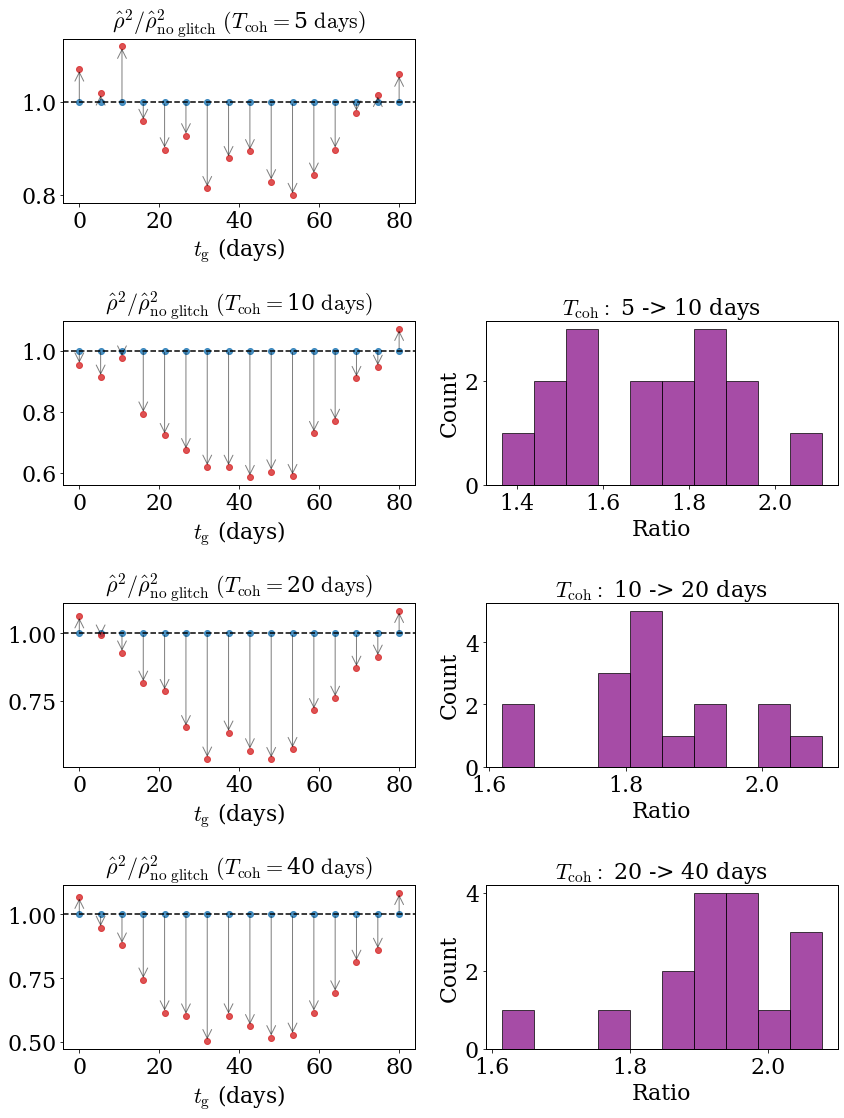

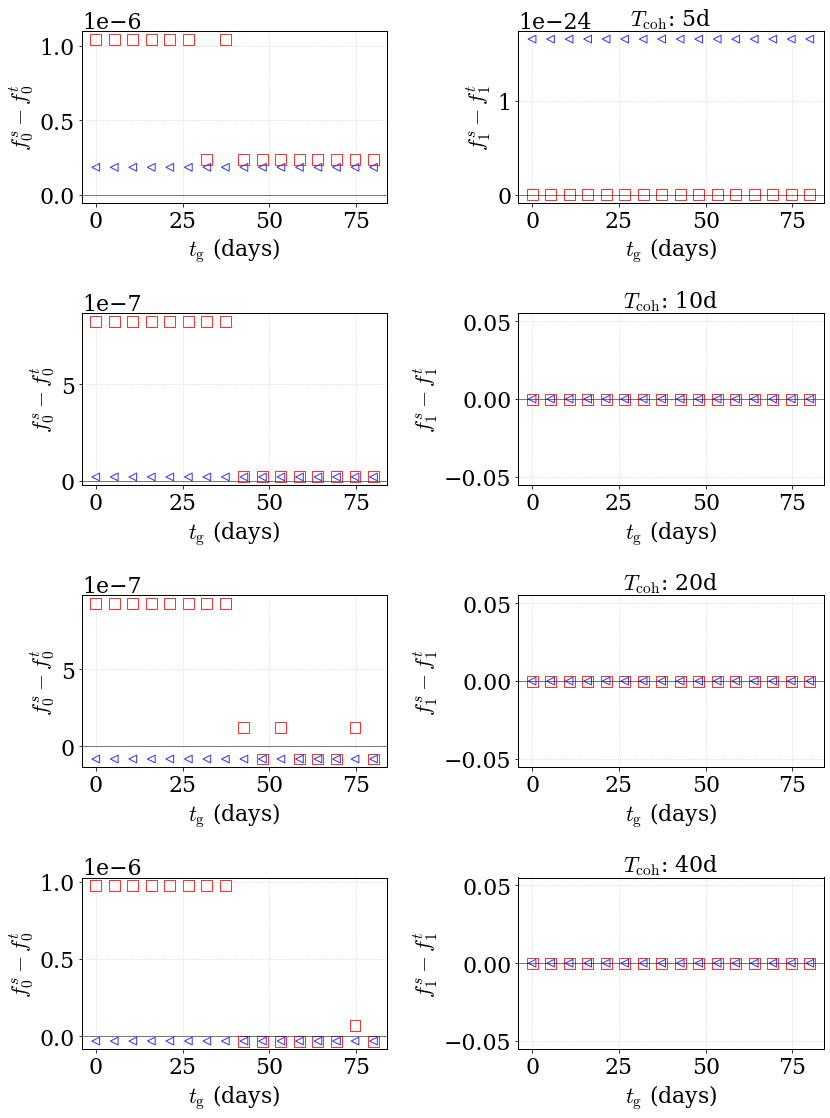

In [5]:
# 1. Define your parameters
data_label = 'wg_dnu_nu_1e-8'
search_label = 'f0'

labels = ['ng_pop'+'_'+search_label, data_label]
    
p_labels = ['No Glitch', 'With Glitch']
durs = ['5d', '10d', '20d', '40d']

# 2. Load the data once
results_obj = load_result(data_label, labels, durs, n_signal=16, homedir=config['home_dir'], single_ng=False)

# 3. Plot whenever you want
fig, ax = plot_fstat_ratio(results_obj, p_labels)
fig.savefig(f'./plots/{labels[1]}_ratio.png')

fig, ax = plot_params_bias(results_obj, p_labels)
fig.savefig(f'./plots/{labels[1]}_params.png')


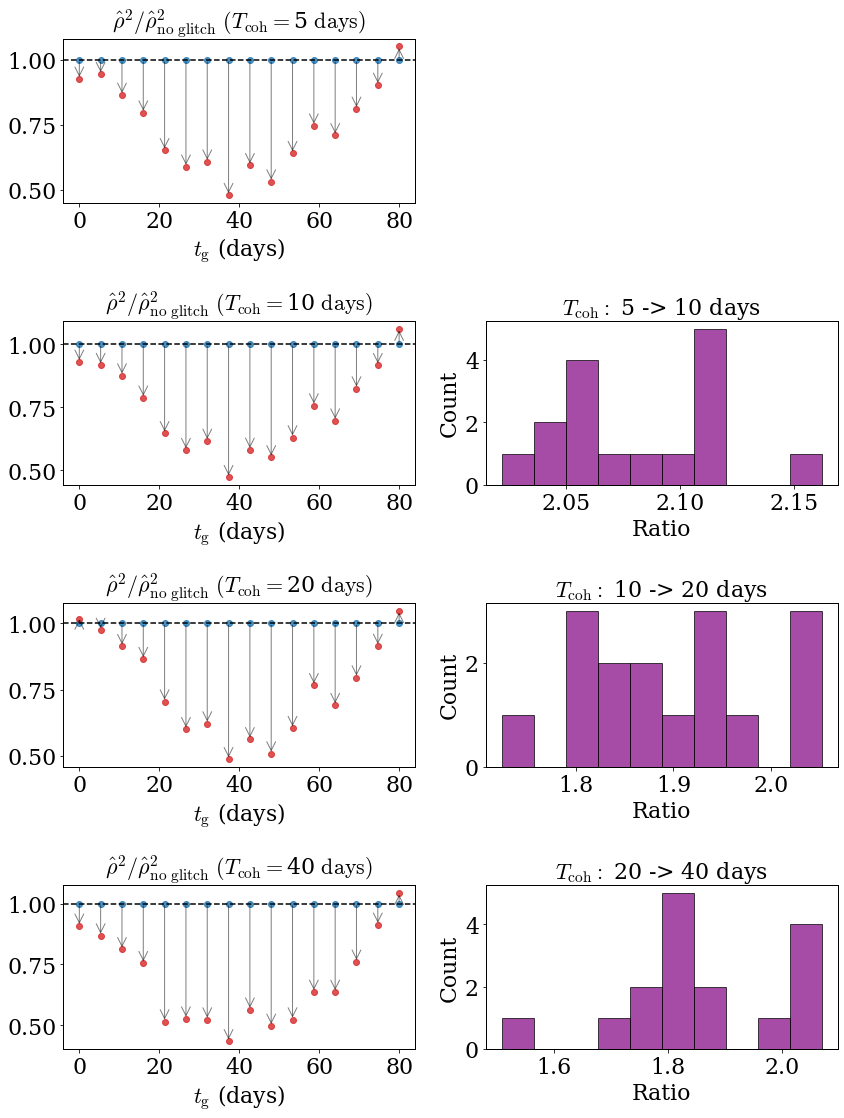

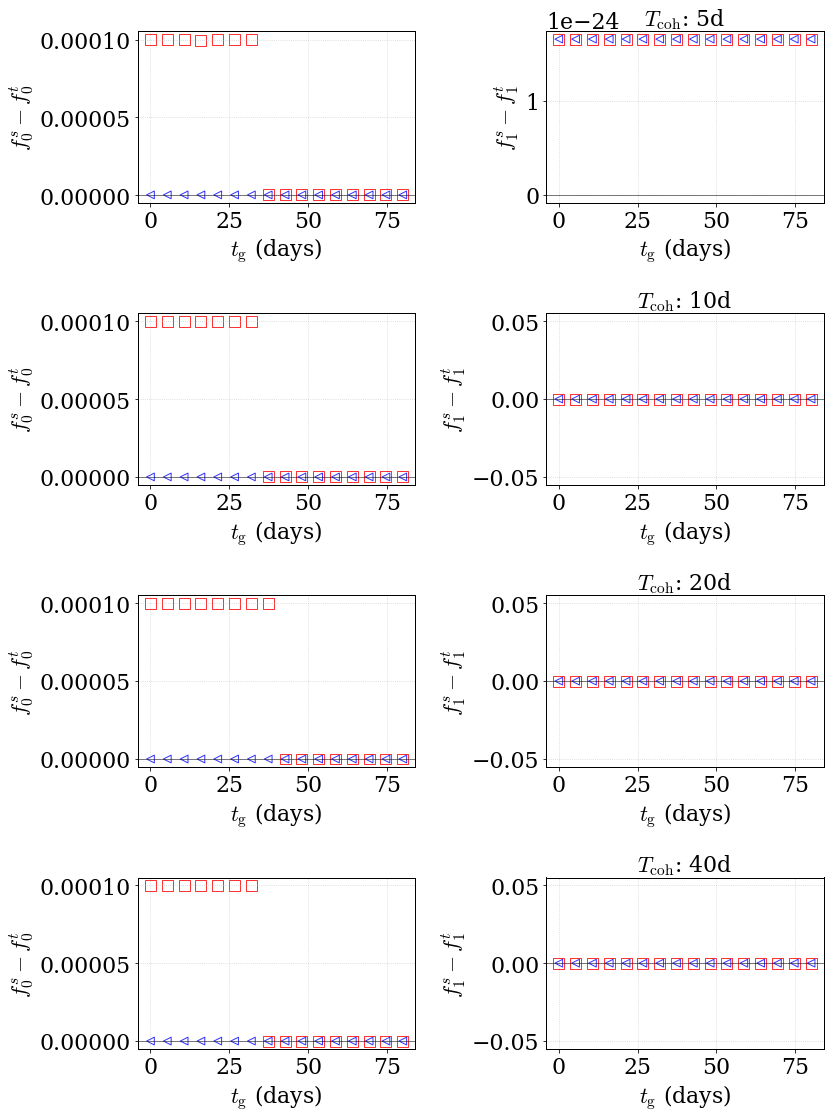

In [4]:
# 1. Define your parameters
data_label = 'wg_dnu_nu_1e-6'
search_label = 'f0'

labels = ['ng_pop'+'_'+search_label, data_label]
    
p_labels = ['No Glitch', 'With Glitch']
durs = ['5d', '10d', '20d', '40d']

# 2. Load the data once
results_obj = load_result(data_label, labels, durs, n_signal=16, homedir=config['home_dir'], single_ng=False)

# 3. Plot whenever you want
fig, ax = plot_fstat_ratio(results_obj, p_labels)
fig.savefig(f'./plots/{labels[1]}_ratio.png')

fig, ax = plot_params_bias(results_obj, p_labels)
fig.savefig(f'./plots/{labels[1]}_params.png')


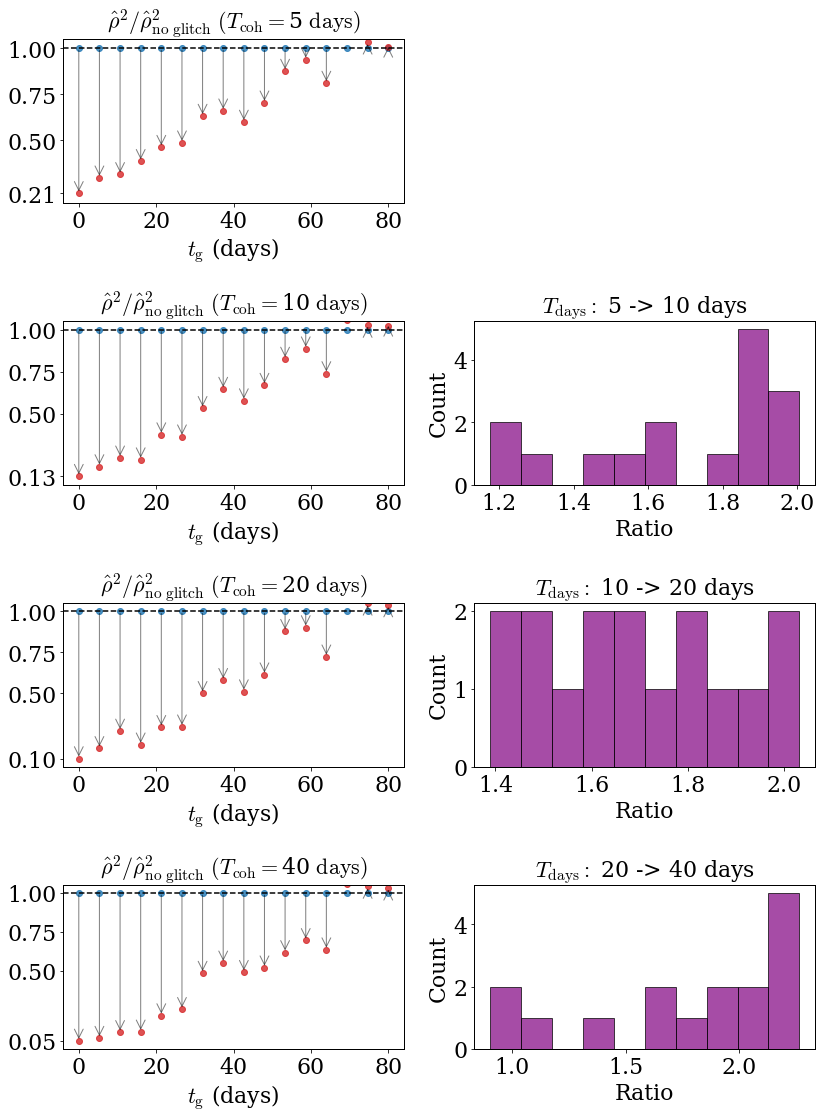

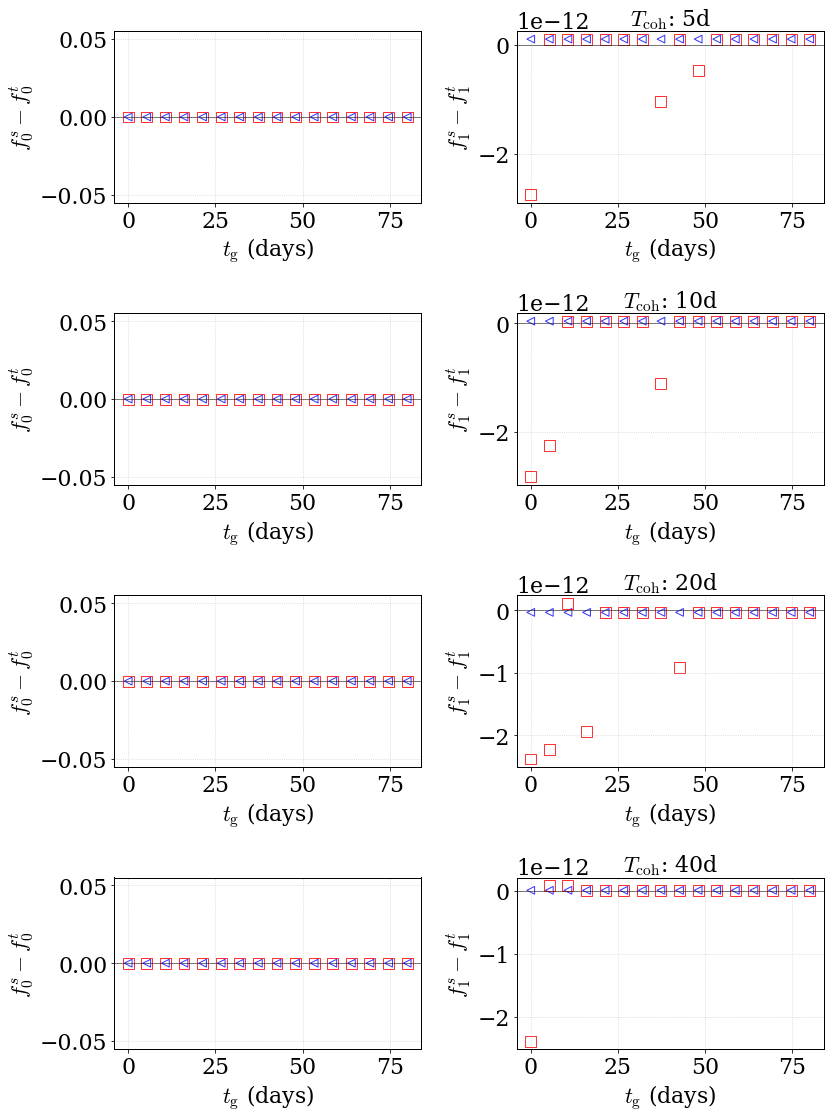

In [44]:
# 1. Define your parameters
data_label = 'wg_dnu1_nu1_1e-4'
search_label = 'f1'

labels = ['ng_pop'+'_'+search_label, data_label]
    
p_labels = ['No Glitch', 'With Glitch']
durs = ['5d', '10d', '20d', '40d']

# 2. Load the data once
results_obj = load_result(data_label, labels, durs, n_signal=16, homedir=config['home_dir'], single_ng=False)

# 3. Plot whenever you want
fig, ax = plot_fstat_ratio(results_obj, p_labels)
fig.savefig(f'./plots/{labels[1]}_ratio.png')

fig, ax = plot_params_bias(results_obj, p_labels)
fig.savefig(f'./plots/{labels[1]}_params.png')


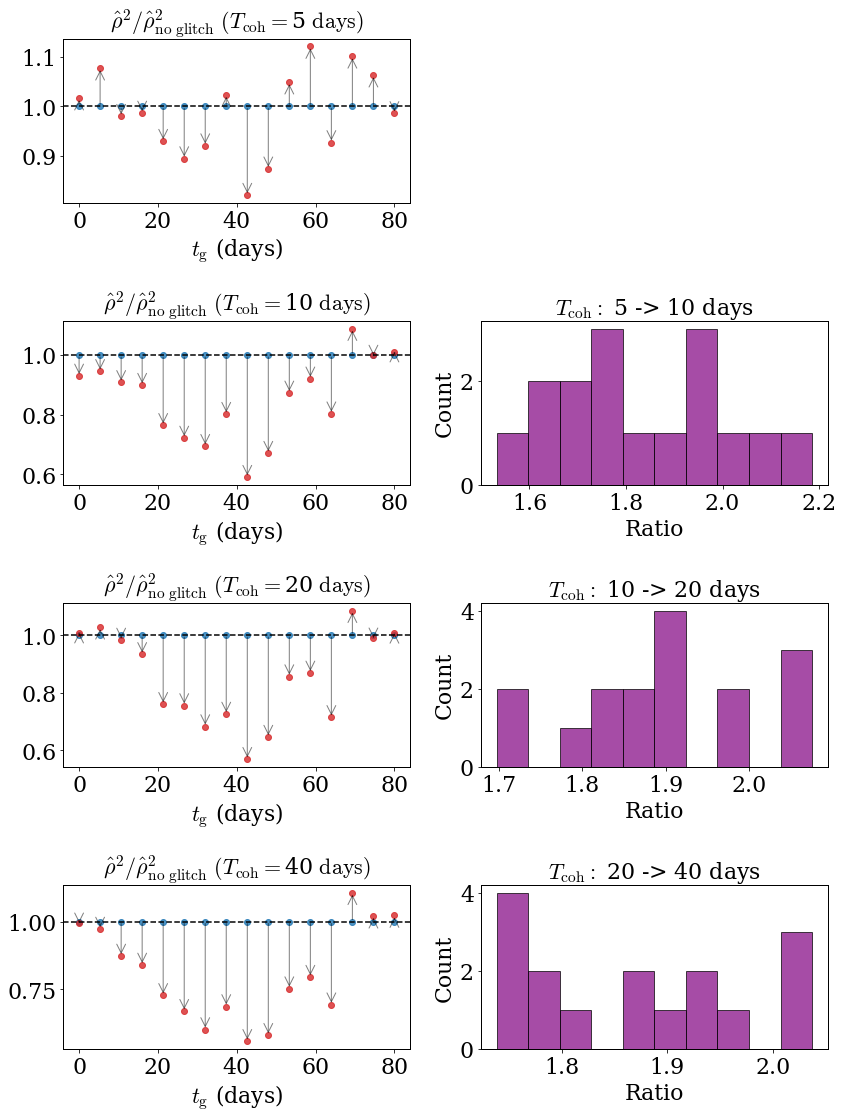

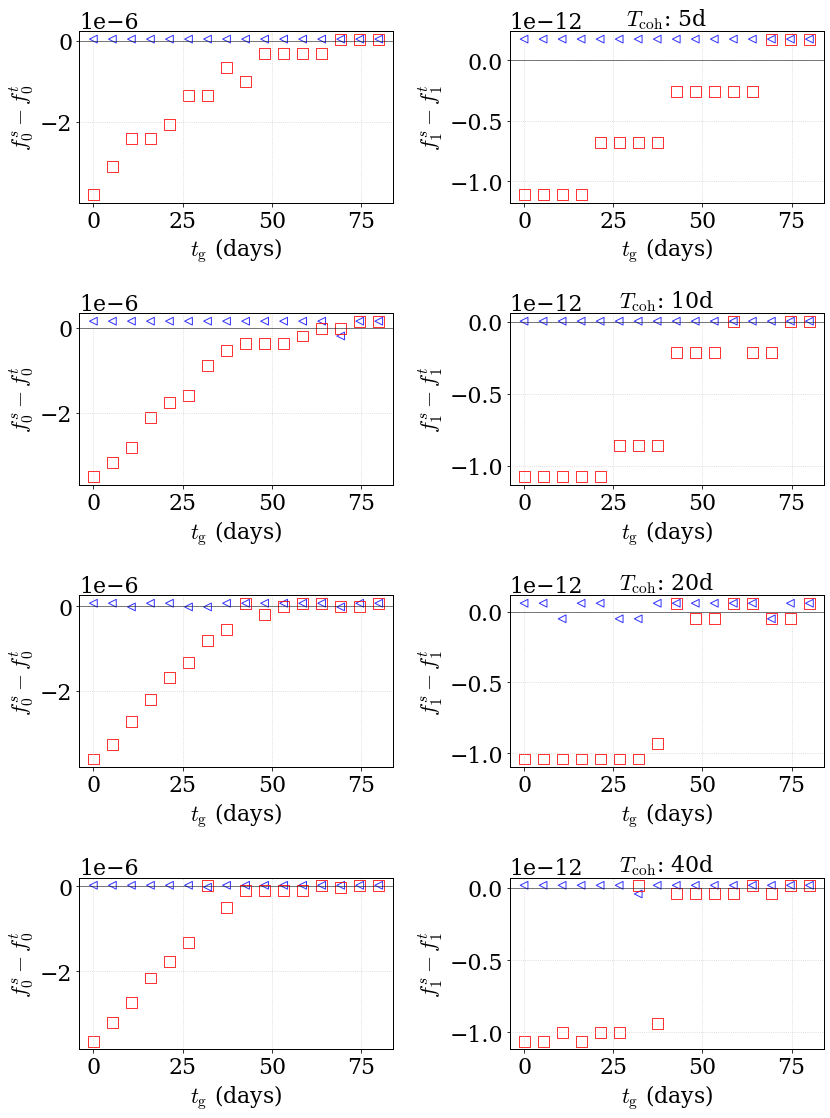

In [6]:
# 1. Define your parameters
data_label = 'wg_dnu1_nu1_1e-4'
search_label = 'f0f1'

labels = ['ng_pop'+'_'+search_label, data_label+'_'+search_label]
    
p_labels = ['No Glitch', 'With Glitch']
durs = ['5d', '10d', '20d', '40d']

# 2. Load the data once
results_obj = load_result(data_label, labels, durs, n_signal=16, homedir=config['home_dir'], single_ng=False)

# 3. Plot whenever you want
fig, ax = plot_fstat_ratio(results_obj, p_labels)
fig.savefig(f'./plots/{labels[1]}_ratio.png')

fig, ax = plot_params_bias(results_obj, p_labels)
fig.savefig(f'./plots/{labels[1]}_params.png')


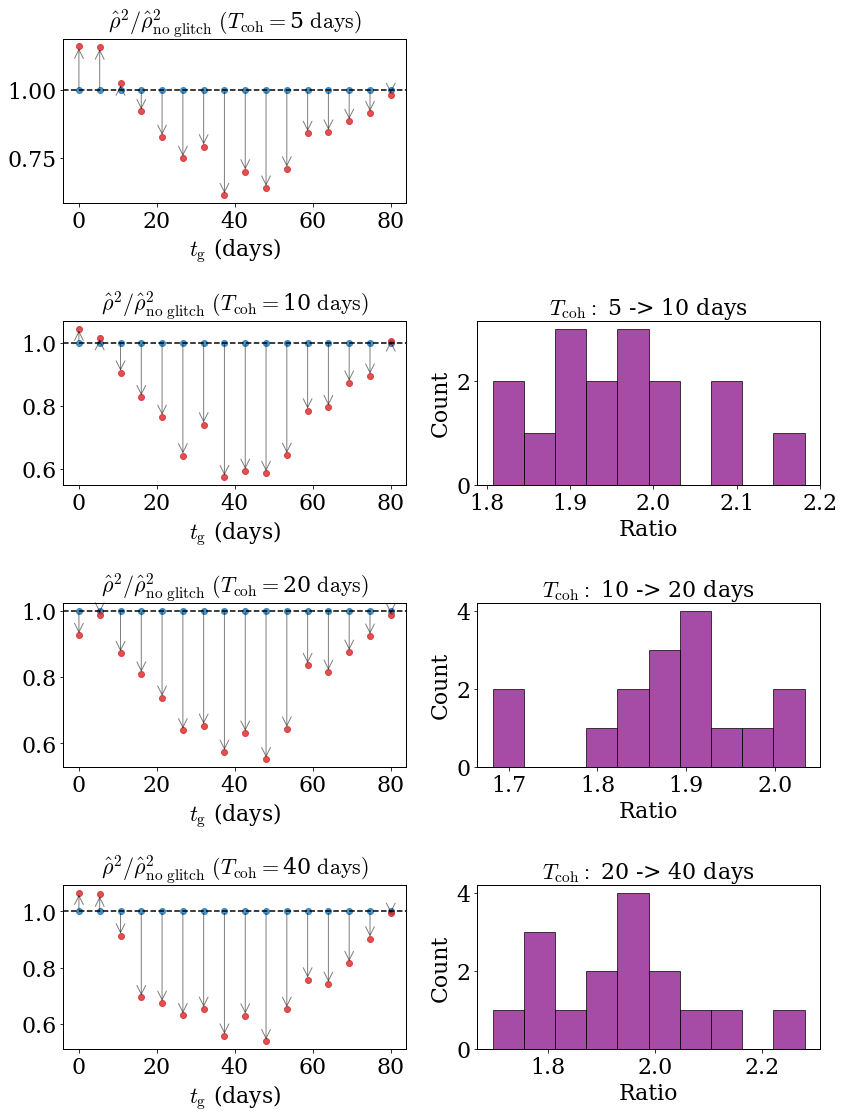

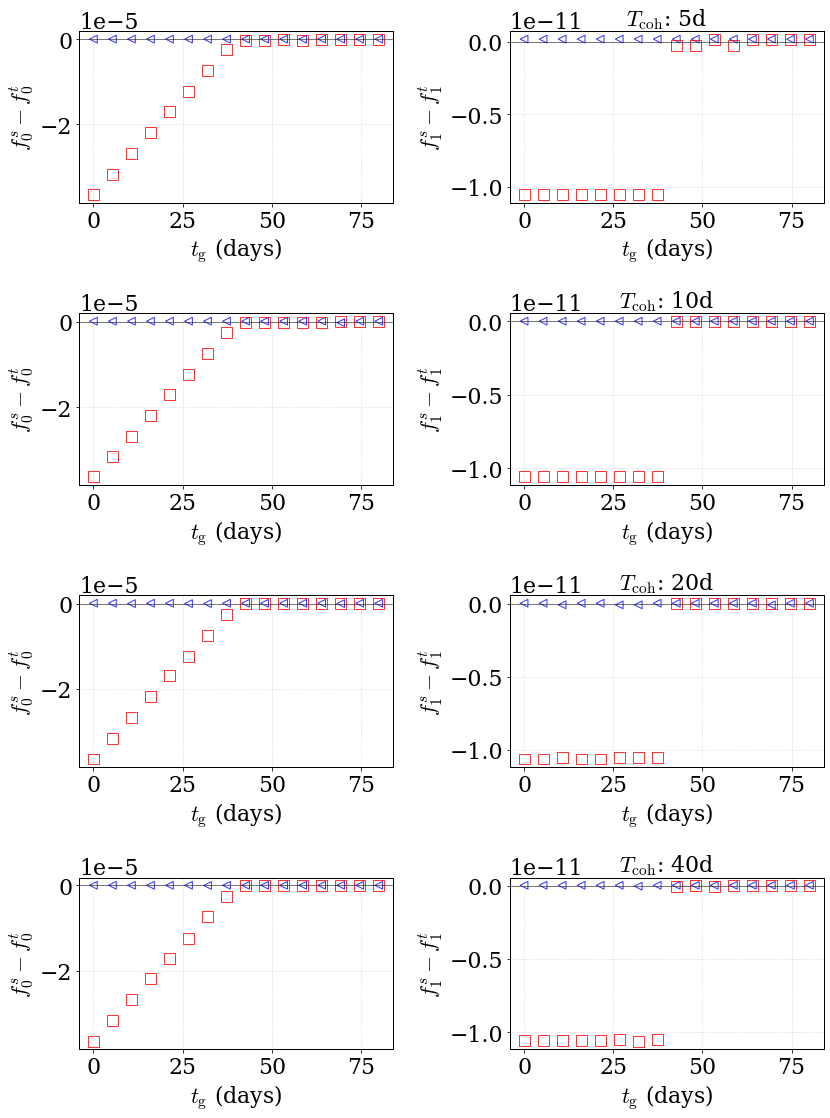

In [7]:
# 1. Define your parameters
data_label = 'wg_dnu1_nu1_1e-3'
search_label = 'f0f1'

labels = ['ng_pop'+'_'+search_label, data_label+'_'+search_label]
    
p_labels = ['No Glitch', 'With Glitch']
durs = ['5d', '10d', '20d', '40d']

# 2. Load the data once
results_obj = load_result(data_label, labels, durs, n_signal=16, homedir=config['home_dir'], single_ng=False)

# 3. Plot whenever you want
fig, ax = plot_fstat_ratio(results_obj, p_labels)
fig.savefig(f'./plots/{labels[1]}_ratio.png')

fig, ax = plot_params_bias(results_obj, p_labels)
fig.savefig(f'./plots/{labels[1]}_params.png')


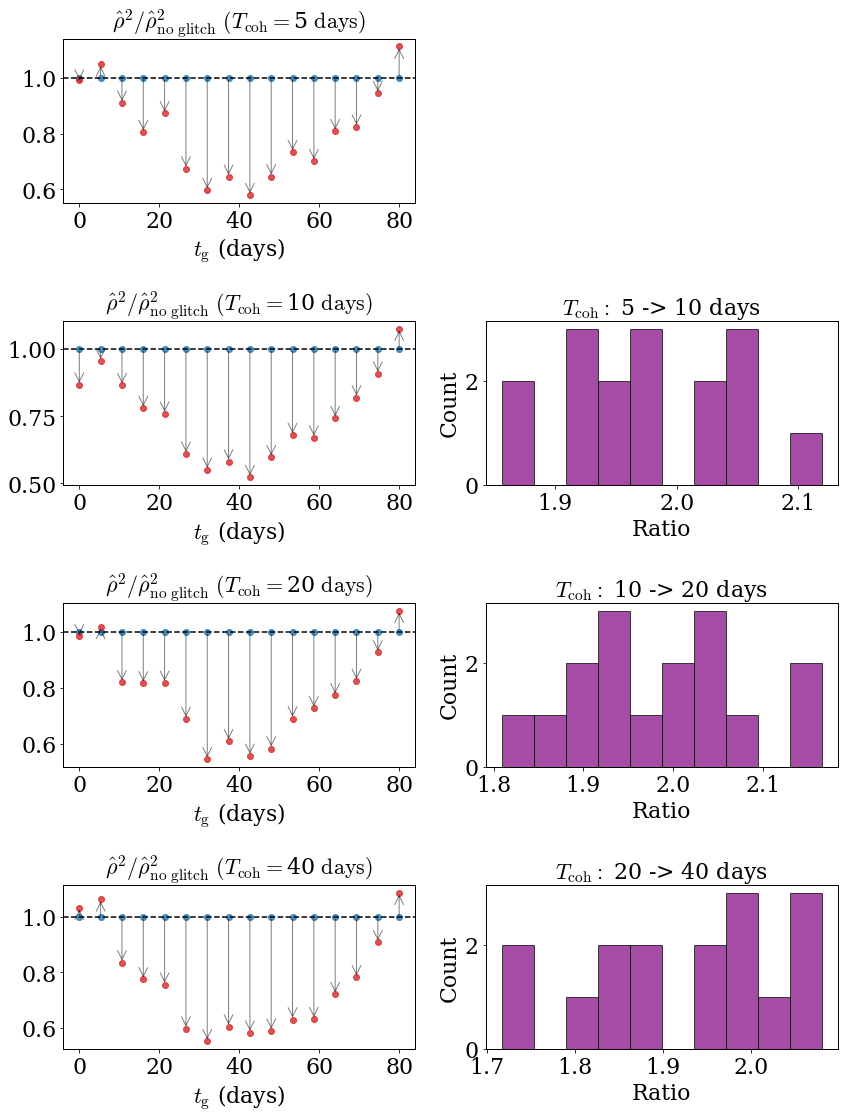

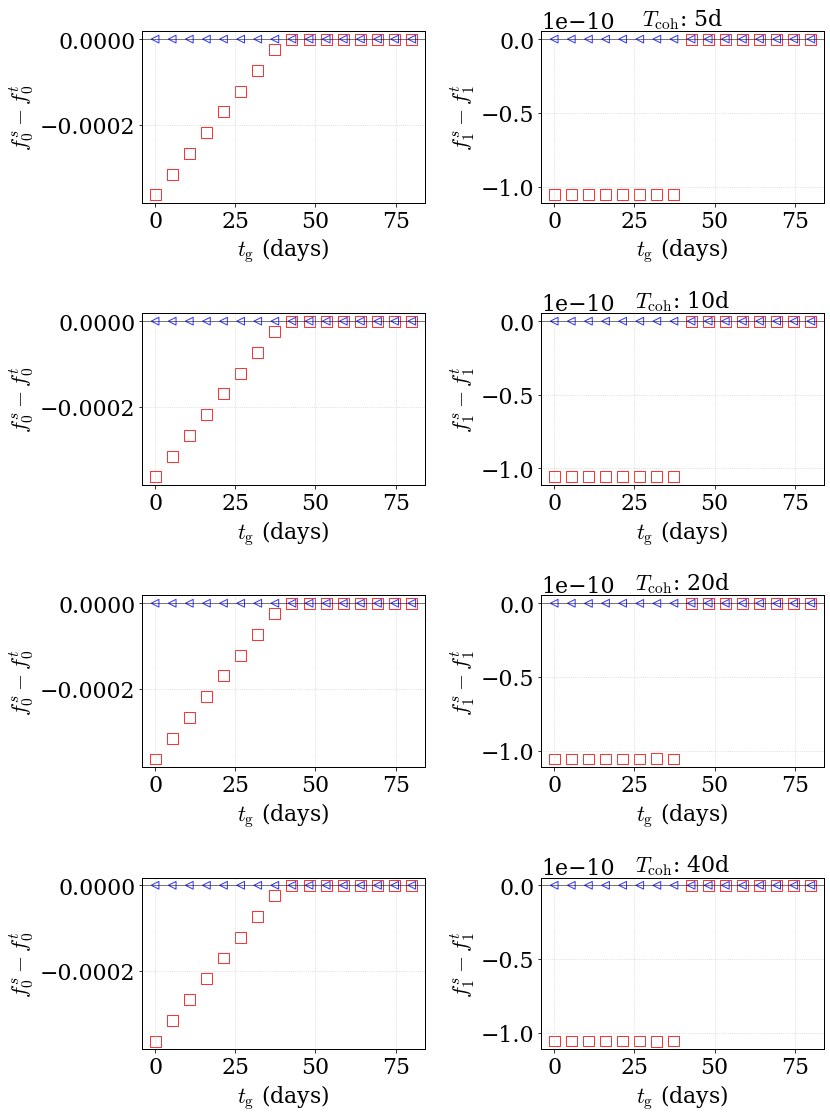

In [8]:
# 1. Define your parameters
data_label = 'wg_dnu1_nu1_1e-2'
search_label = 'f0f1'

labels = ['ng_pop'+'_'+search_label, data_label+'_'+search_label]
    
p_labels = ['No Glitch', 'With Glitch']
durs = ['5d', '10d', '20d', '40d']

# 2. Load the data once
results_obj = load_result(data_label, labels, durs, n_signal=16, homedir=config['home_dir'], single_ng=False)

# 3. Plot whenever you want
fig, ax = plot_fstat_ratio(results_obj, p_labels)
fig.savefig(f'./plots/{labels[1]}_ratio.png')

fig, ax = plot_params_bias(results_obj, p_labels)
fig.savefig(f'./plots/{labels[1]}_params.png')


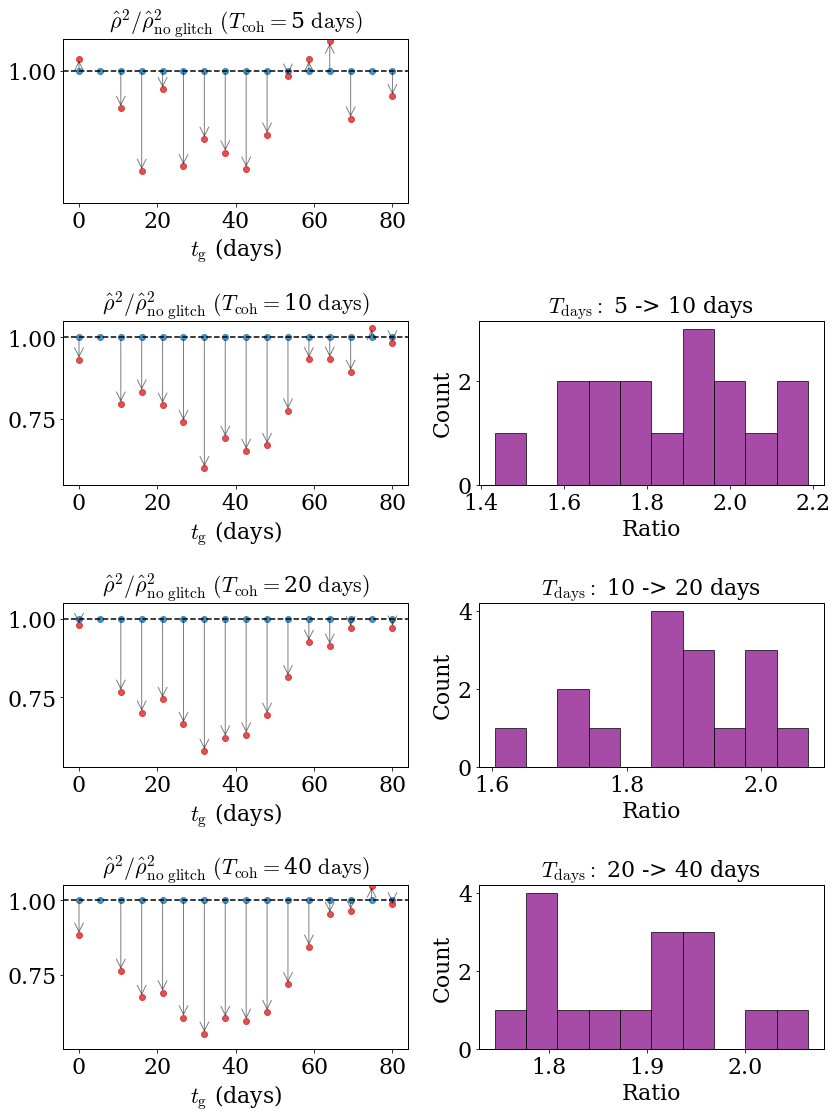

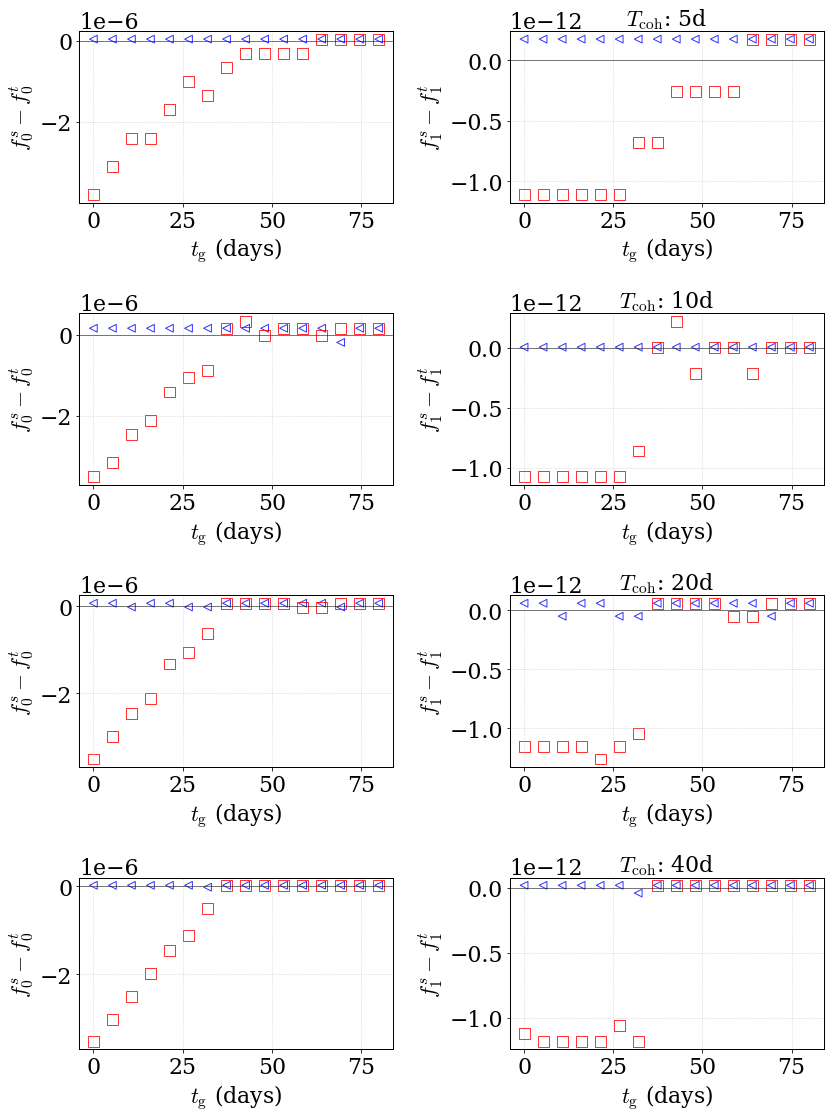

In [49]:
# 1. Define your parameters
data_label = 'wg_dnu_nu_1e-8_dnu1_nu1_1e-4_q_1'
search_label = 'f0f1'

labels = ['ng_pop'+'_'+search_label, data_label+'_'+search_label]
    
p_labels = ['No Glitch', 'With Glitch']
durs = ['5d', '10d', '20d', '40d']

# 2. Load the data once
results_obj = load_result(data_label, labels, durs, n_signal=16, homedir=config['home_dir'], single_ng=False)

# 3. Plot whenever you want
fig, ax = plot_fstat_ratio(results_obj, p_labels)
fig.savefig(f'./plots/{labels[1]}_ratio.png')

fig, ax = plot_params_bias(results_obj, p_labels)
fig.savefig(f'./plots/{labels[1]}_params.png')


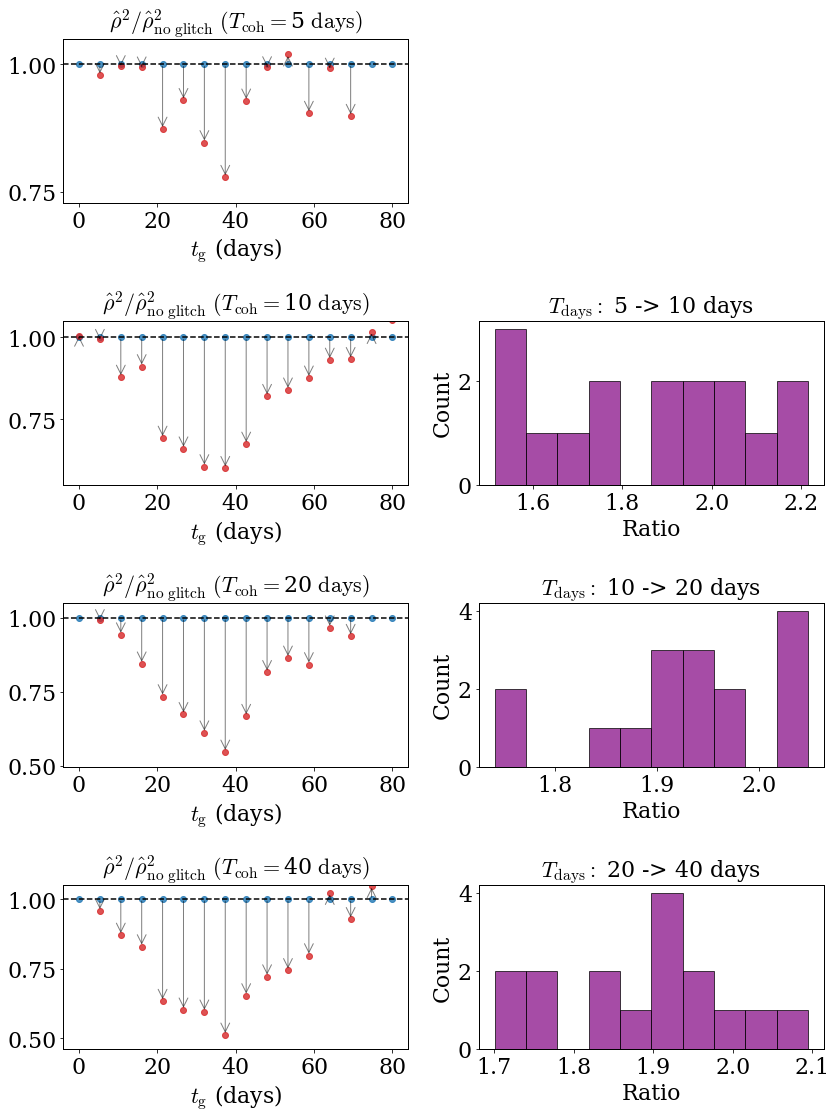

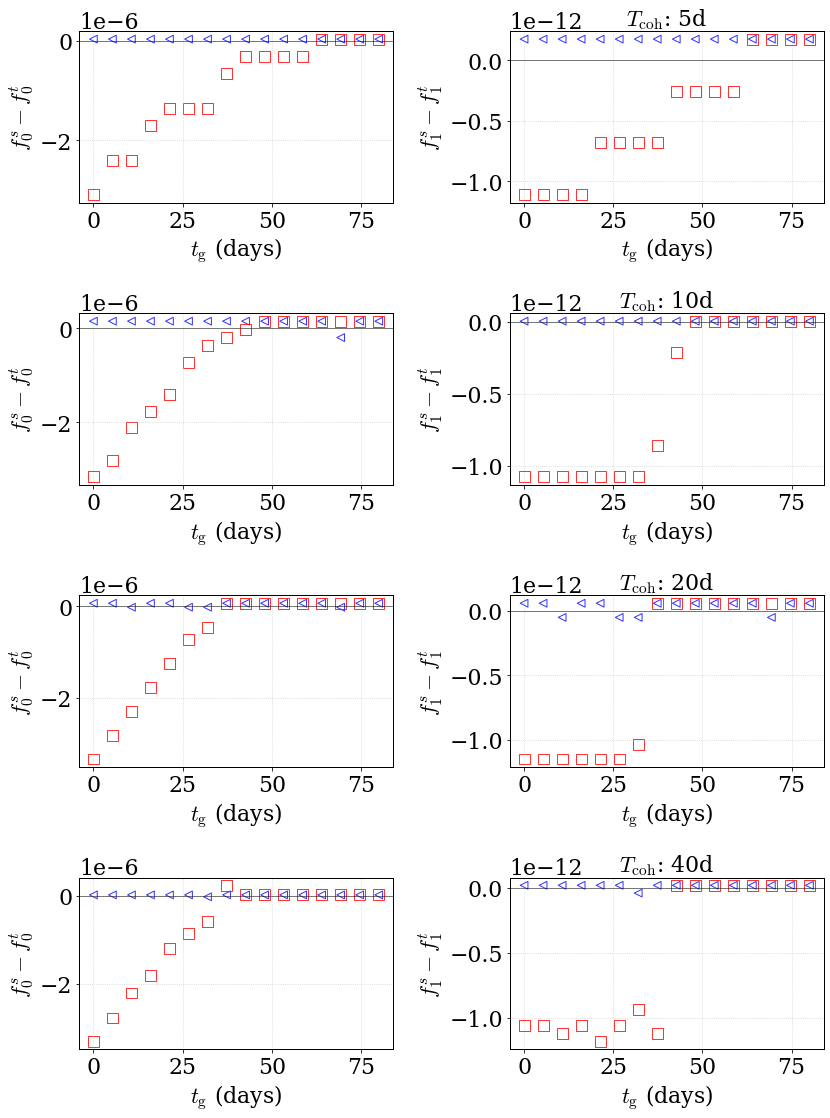

In [50]:
# 1. Define your parameters
data_label = 'wg_dnu_nu_1e-8_dnu1_nu1_1e-4_q_0.7'
search_label = 'f0f1'

labels = ['ng_pop'+'_'+search_label, data_label+'_'+search_label]
    
p_labels = ['No Glitch', 'With Glitch']
durs = ['5d', '10d', '20d', '40d']

# 2. Load the data once
results_obj = load_result(data_label, labels, durs, n_signal=16, homedir=config['home_dir'], single_ng=False)

# 3. Plot whenever you want
fig, ax = plot_fstat_ratio(results_obj, p_labels)
fig.savefig(f'./plots/{labels[1]}_ratio.png')

fig, ax = plot_params_bias(results_obj, p_labels)
fig.savefig(f'./plots/{labels[1]}_params.png')


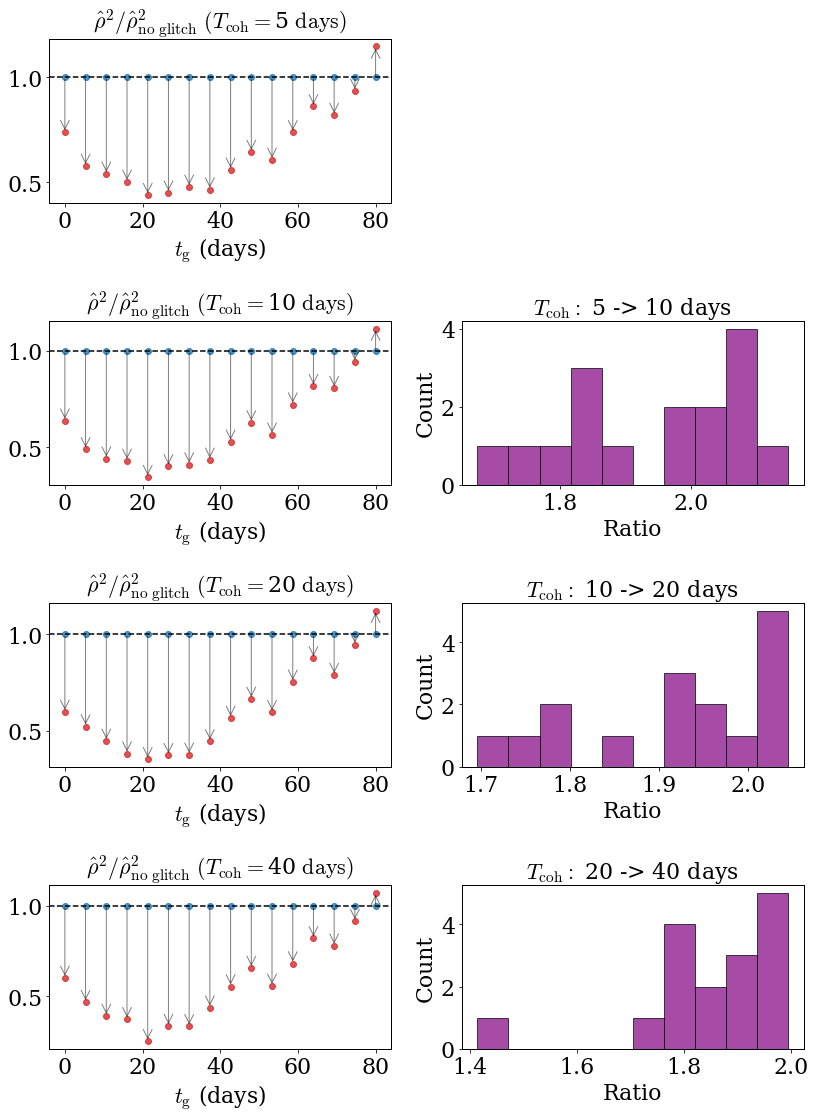

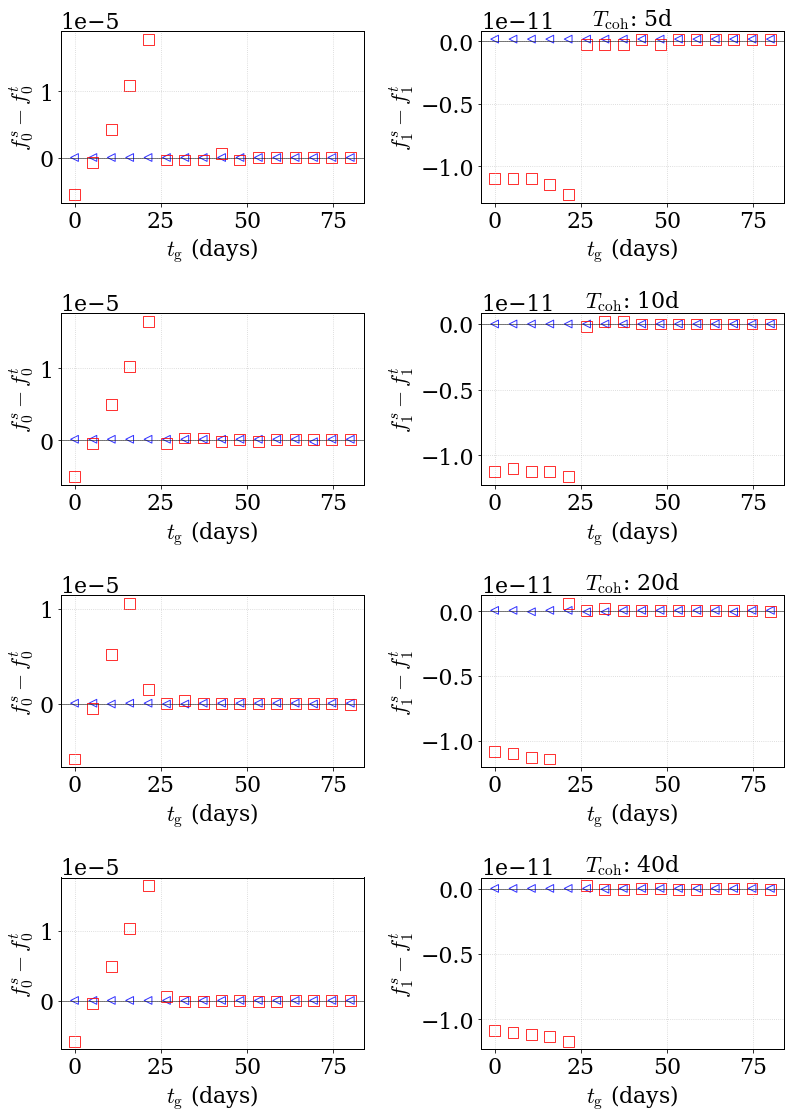

In [9]:
# 1. Define your parameters
data_label = 'wg_dnu_nu_1e-6_dnu1_nu1_1e-3_q_0.7'
search_label = 'f0f1'

labels = ['ng_pop'+'_'+search_label, data_label+'_'+search_label]
    
p_labels = ['No Glitch', 'With Glitch']
durs = ['5d', '10d', '20d', '40d']

# 2. Load the data once
results_obj = load_result(data_label, labels, durs, n_signal=16, homedir=config['home_dir'], single_ng=False)

# 3. Plot whenever you want
fig, ax = plot_fstat_ratio(results_obj, p_labels)
fig.savefig(f'./plots/{labels[1]}_ratio.png')

fig, ax = plot_params_bias(results_obj, p_labels)
fig.savefig(f'./plots/{labels[1]}_params.png')
